In [55]:
import zipfile
import os

zip_path = "/content/training.zip"
extract_path = "/content/training"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


CNN MODEL :

In [56]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [57]:
!nvidia-smi

Sun Aug 23 04:30:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P0             28W /   70W |    6145MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [58]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [59]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 50

In [60]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/training/training/archive/PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [61]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

(32, 256, 256, 3)
[0 0 1 0 0 1 1 1 1 1 0 0 0 0 1 1 0 0 0 1 0 1 0 1 1 0 0 0 0 0 2 0]


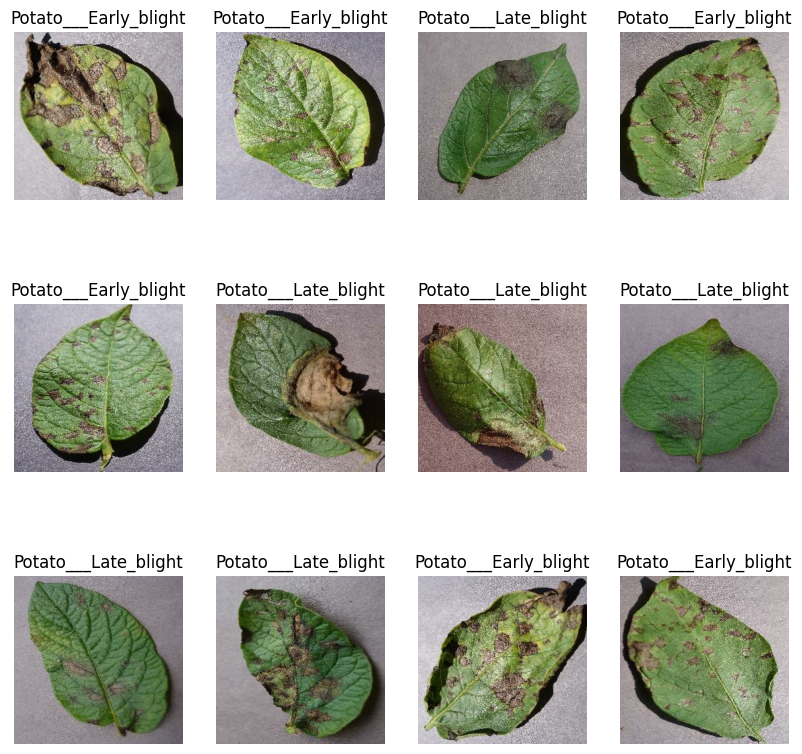

In [62]:
plt.figure(figsize=(10, 10))

for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

80% → Training
20% → Test

Within the 20% test:
10% → Validation
10% → Test

In [63]:
train_size = 0.8
len(dataset) * train_size

54.400000000000006

In [64]:
train_ds = dataset.take(54)
len(train_ds)

54

In [65]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [66]:
val_size = 0.1
len(dataset) * val_size

6.800000000000001

In [67]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [68]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [69]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=1000):

    assert (train_split + test_split + val_split) == 1

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    test_size = int(test_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds

In [70]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [71]:
len(train_ds)

54

In [72]:
len(val_ds)

6

In [73]:
len(test_ds)

8

In [74]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [75]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch[0].numpy()/255)

[[[0.5568628  0.5254902  0.5686275 ]
  [0.5647059  0.53333336 0.5764706 ]
  [0.5882353  0.5568628  0.6       ]
  ...
  [0.5647059  0.52156866 0.5529412 ]
  [0.6117647  0.5686275  0.6       ]
  [0.54901963 0.5058824  0.5372549 ]]

 [[0.6431373  0.6117647  0.654902  ]
  [0.6431373  0.6117647  0.654902  ]
  [0.6392157  0.60784316 0.6509804 ]
  ...
  [0.5176471  0.4745098  0.5058824 ]
  [0.5411765  0.49803922 0.5294118 ]
  [0.47843137 0.43529412 0.46666667]]

 [[0.6313726  0.6        0.6431373 ]
  [0.63529414 0.6039216  0.64705884]
  [0.63529414 0.6039216  0.64705884]
  ...
  [0.47058824 0.42745098 0.45882353]
  [0.5058824  0.4627451  0.49411765]
  [0.47843137 0.43529412 0.46666667]]

 ...

 [[0.7647059  0.7254902  0.72156864]
  [0.75686276 0.7176471  0.7137255 ]
  [0.7490196  0.70980394 0.7058824 ]
  ...
  [0.46666667 0.41960785 0.43529412]
  [0.4627451  0.41568628 0.43137255]
  [0.67058825 0.62352943 0.6392157 ]]

 [[0.7490196  0.70980394 0.7058824 ]
  [0.74509805 0.7058824  0.7019608 ]


In [76]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0 / 255)
])

In [77]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [78]:
IMAGE_SIZE

256

In [79]:
CHANNELS

3

In [80]:
BATCH_SIZE

32

BUILDING CNN MODEL

In [81]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3
model = models.Sequential([
    resize_and_rescale,
    data_augmentation,

    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])
model.build(input_shape=input_shape)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [82]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [84]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.4959 - loss: 0.9048 - val_accuracy: 0.4479 - val_loss: 0.8597
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.6794 - loss: 0.6927 - val_accuracy: 0.8229 - val_loss: 0.4501
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.8171 - loss: 0.4267 - val_accuracy: 0.7448 - val_loss: 0.4604
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.8663 - loss: 0.3041 - val_accuracy: 0.8750 - val_loss: 0.3370
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.8831 - loss: 0.2892 - val_accuracy: 0.8958 - val_loss: 0.2572
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9207 - loss: 0.2067 - val_accuracy: 0.9219 - val_loss: 0.2361
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9109 - loss: 0.2242 - val_accuracy: 0.9115 - val_loss: 0.2332
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9277 - loss: 0.1896 - val_accuracy: 0.9323 - v

In [ ]:
len(test_ds)

In [85]:
scores=model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9727 - loss: 0.1009


In [86]:
scores

[0.10091030597686768, 0.97265625]

In [87]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [88]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [90]:
len(history.history['loss'])

50

In [91]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

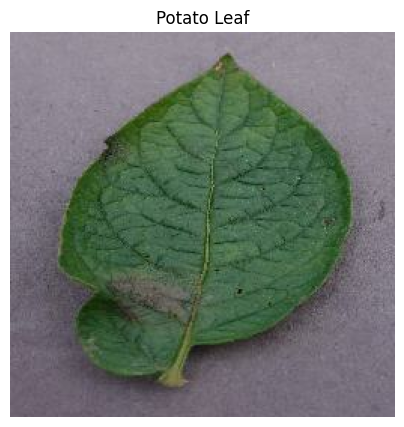

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Actual Disease   : Potato___Late_blight
Predicted Disease: Potato___Late_blight
Confidence       : 99.98%


In [119]:
import numpy as np
import matplotlib.pyplot as plt

for images_batch, labels_batch in test_ds.take(1):

    # Get first image
    first_image = images_batch[0].numpy().astype("uint8")

    # Display image
    plt.figure(figsize=(5, 5))
    plt.imshow(first_image)
    plt.axis("off")
    plt.title("Potato Leaf")
    plt.show()

    # Actual label
    actual_label = labels_batch[0].numpy()

    # Prediction
    batch_prediction = model.predict(images_batch)

    predicted_label = np.argmax(batch_prediction[0])

    # Confidence
    confidence = np.max(batch_prediction[0]) * 100

    # Display results
    print("Actual Disease   :", class_names[actual_label])
    print("Predicted Disease:", class_names[predicted_label])
    print("Confidence       :", f"{confidence:.2f}%")

In [128]:
from google.colab import files

uploaded = files.upload()

Saving test-2.jpg to test-2.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


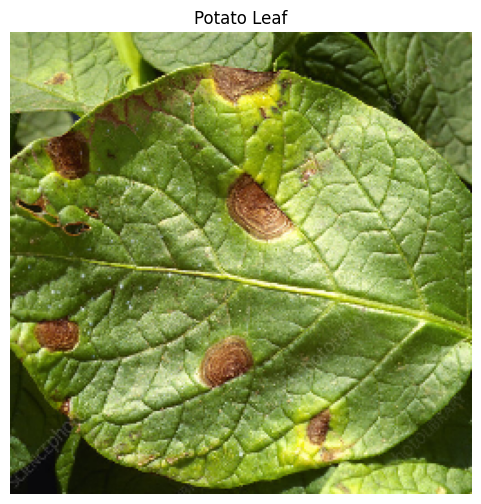

Predicted Disease: Potato___Early_blight
Confidence        : 100.00%


In [129]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Get uploaded image filename
image_path = list(uploaded.keys())[0]

# Load image
img = tf.keras.utils.load_img(
    image_path,
    target_size=(IMAGE_SIZE, IMAGE_SIZE)
)

# Convert image to array
img_array = tf.keras.utils.img_to_array(img)

# Add batch dimension
img_batch = tf.expand_dims(img_array, 0)

# Predict
prediction = model.predict(img_batch)

# Get predicted class
predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]

# Get confidence
confidence = np.max(prediction[0]) * 100

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Potato Leaf")
plt.show()

# Display prediction
print("Predicted Disease:", predicted_class)
print("Confidence        :", f"{confidence:.2f}%")

In [120]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create a batch

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)

    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


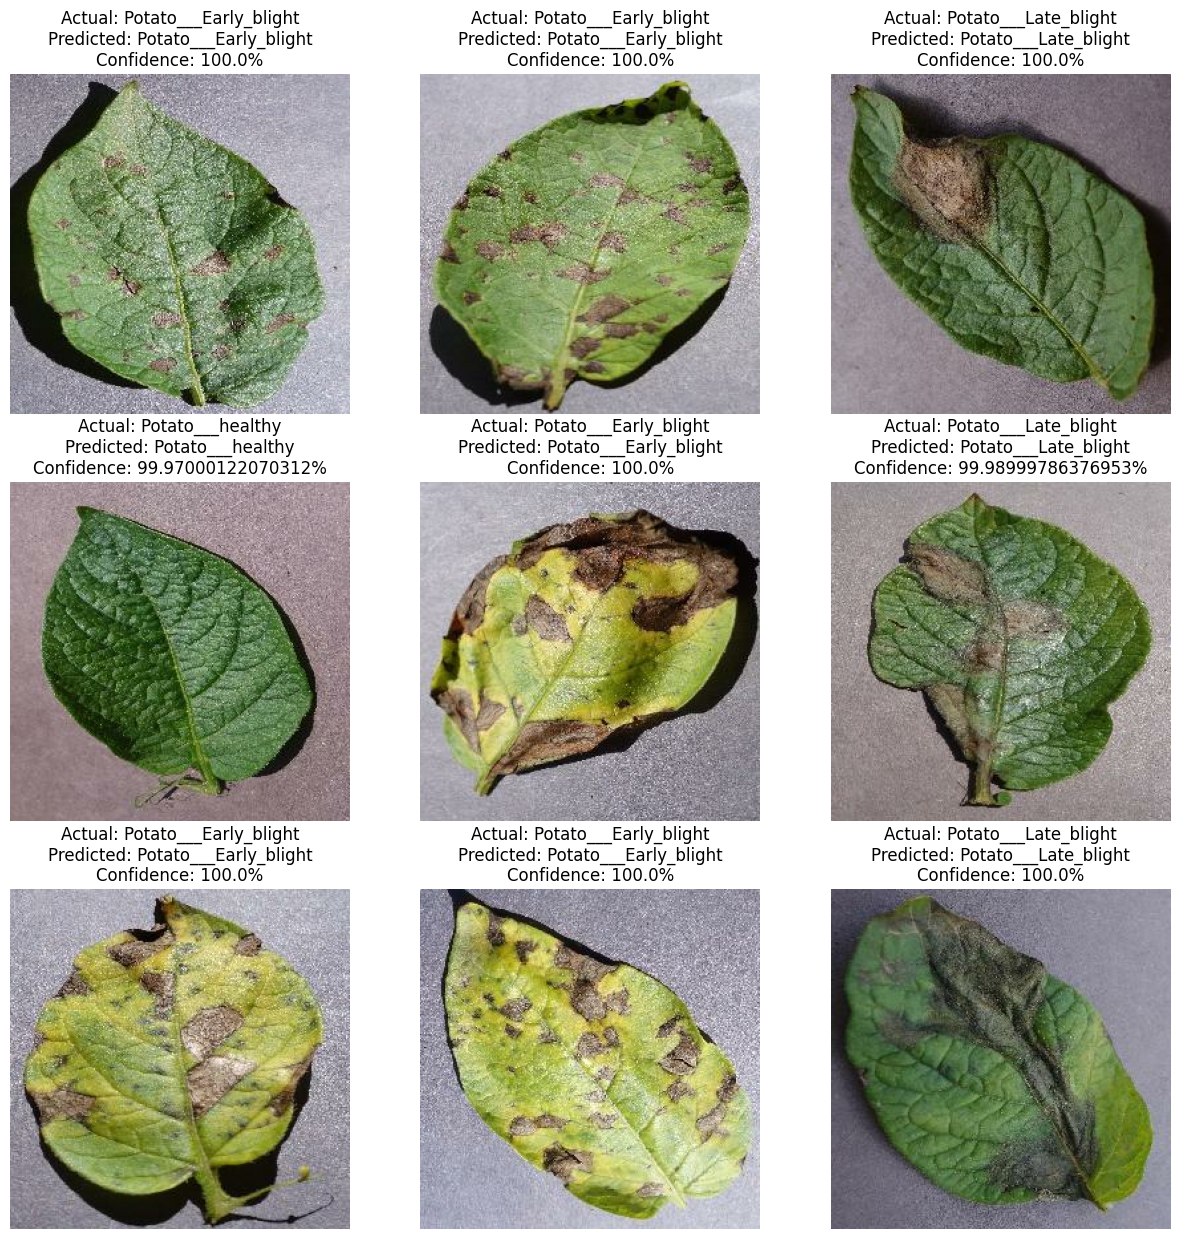

In [125]:
plt.figure(figsize=(15,15))
for images, labels in test_ds.take(1):
    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(
            model,
            images[i].numpy()
        )

        actual_class = class_names[labels[i]]

        plt.title(
            f"Actual: {actual_class}\n"
            f"Predicted: {predicted_class}\n"
            f"Confidence: {confidence}%"
        )

        plt.axis("off")

PLOT TRAINING HISTORY ON GRAPH

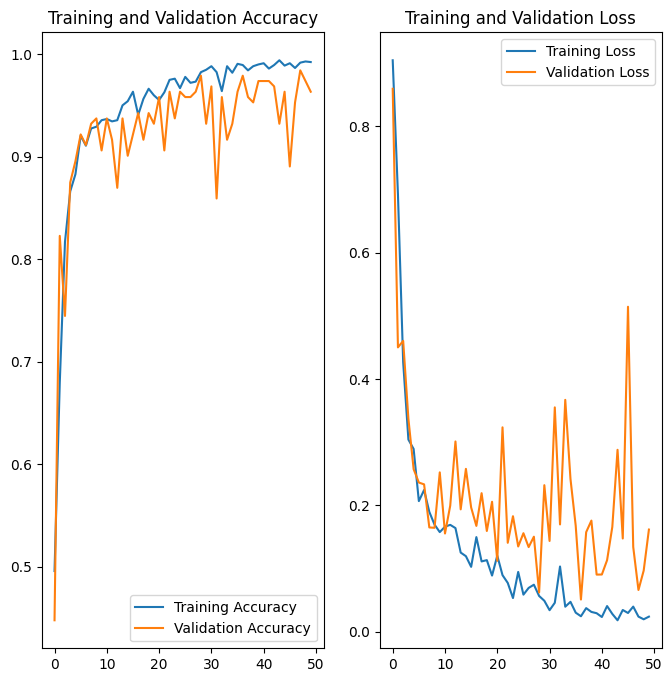

In [92]:
plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [93]:
scores = model.evaluate(test_ds)
print("Test Loss:", scores[0])
print("Test Accuracy:", scores[1])

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9727 - loss: 0.1009
Test Loss: 0.10091029852628708
Test Accuracy: 0.97265625


In [94]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt

ResNet50 model

In [95]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
)

base_model.trainable = False

model_resnet = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),

    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(3, activation="softmax")
])

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [96]:
model_resnet.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [97]:
EPOCHS_RESNET = 20

history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_RESNET,
    verbose=1
)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 184ms/step - accuracy: 0.8953 - loss: 0.2905 - val_accuracy: 0.9896 - val_loss: 0.0406
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.9809 - loss: 0.0605 - val_accuracy: 1.0000 - val_loss: 0.0212
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.9913 - loss: 0.0340 - val_accuracy: 1.0000 - val_loss: 0.0164
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.9936 - loss: 0.0258 - val_accuracy: 0.9948 - val_loss: 0.0156
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.9954 - loss: 0.0174 - val_accuracy: 1.0000 - val_loss: 0.0070
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.9965 - loss: 0.0133 - val_accuracy: 0.9948 - val_loss: 0.0143
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.9954 - loss: 0.0160 - val_accuracy: 1.0000 - val_loss: 0.0085
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.9954 - loss: 0.0146 - val_accuracy: 1

In [98]:
scores_resnet = model_resnet.evaluate(test_ds)

print("Test Loss:", scores_resnet[0])
print("Test Accuracy:", scores_resnet[1])

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 1.0000 - loss: 0.0017
Test Loss: 0.0016580646624788642
Test Accuracy: 1.0


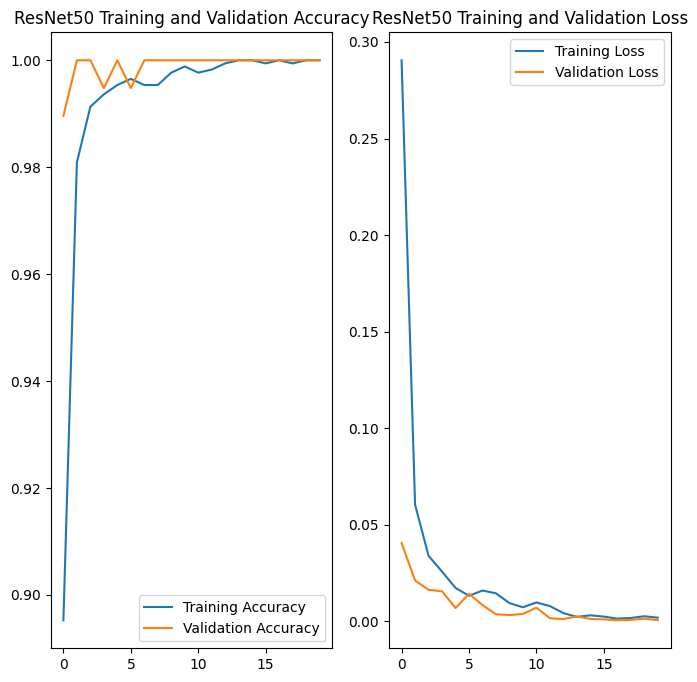

In [99]:
acc = history_resnet.history["accuracy"]
val_acc = history_resnet.history["val_accuracy"]

loss = history_resnet.history["loss"]
val_loss = history_resnet.history["val_loss"]

plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS_RESNET), acc, label="Training Accuracy")
plt.plot(range(EPOCHS_RESNET), val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("ResNet50 Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS_RESNET), loss, label="Training Loss")
plt.plot(range(EPOCHS_RESNET), val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("ResNet50 Training and Validation Loss")

plt.show()

In [100]:
print("Test samples:", len(test_ds) * BATCH_SIZE)
print("Test Accuracy:", scores_resnet[1])

Test samples: 256
Test Accuracy: 1.0


                       precision    recall  f1-score   support

Potato___Early_blight       1.00      1.00      1.00       135
 Potato___Late_blight       1.00      1.00      1.00       107
     Potato___healthy       1.00      1.00      1.00        14

             accuracy                           1.00       256
            macro avg       1.00      1.00      1.00       256
         weighted avg       1.00      1.00      1.00       256



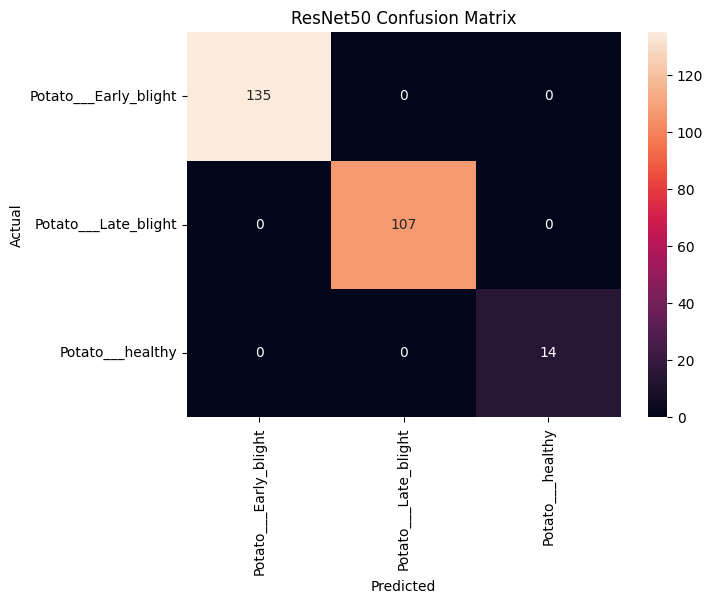

In [101]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model_resnet.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")
plt.show()

VGG16 MODEL


In [102]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

In [103]:
base_model_vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
)

base_model_vgg.trainable = False

model_vgg = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),

    layers.Lambda(preprocess_input),

    base_model_vgg,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(3, activation="softmax")
])

model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,739 (56.38 MB)

 Trainable params: 66,051 (258.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [104]:
model_vgg.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [105]:
EPOCHS_VGG = 20

history_vgg = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_VGG,
    verbose=1
)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 268ms/step - accuracy: 0.8125 - loss: 0.7882 - val_accuracy: 0.9688 - val_loss: 0.0977
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 249ms/step - accuracy: 0.9531 - loss: 0.1346 - val_accuracy: 0.9896 - val_loss: 0.0331
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 247ms/step - accuracy: 0.9693 - loss: 0.0920 - val_accuracy: 0.9896 - val_loss: 0.0371
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 245ms/step - accuracy: 0.9774 - loss: 0.0631 - val_accuracy: 0.9896 - val_loss: 0.0260
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 246ms/step - accuracy: 0.9844 - loss: 0.0449 - val_accuracy: 0.9896 - val_loss: 0.0226
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 248ms/step - accuracy: 0.9878 - loss: 0.0366 - val_accuracy: 0.9948 - val_loss: 0.0196
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 247ms/step - accuracy: 0.9907 - loss: 0.0294 - val_accuracy: 0.9948 - val_loss: 0.0147
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 247ms/step - accuracy: 0.9931 - loss: 0.0249 - val_accu

In [106]:
scores_vgg = model_vgg.evaluate(test_ds)

print("Test Loss:", scores_vgg[0])
print("Test Accuracy:", scores_vgg[1])

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 220ms/step - accuracy: 1.0000 - loss: 0.0049
Test Loss: 0.004878649488091469
Test Accuracy: 1.0


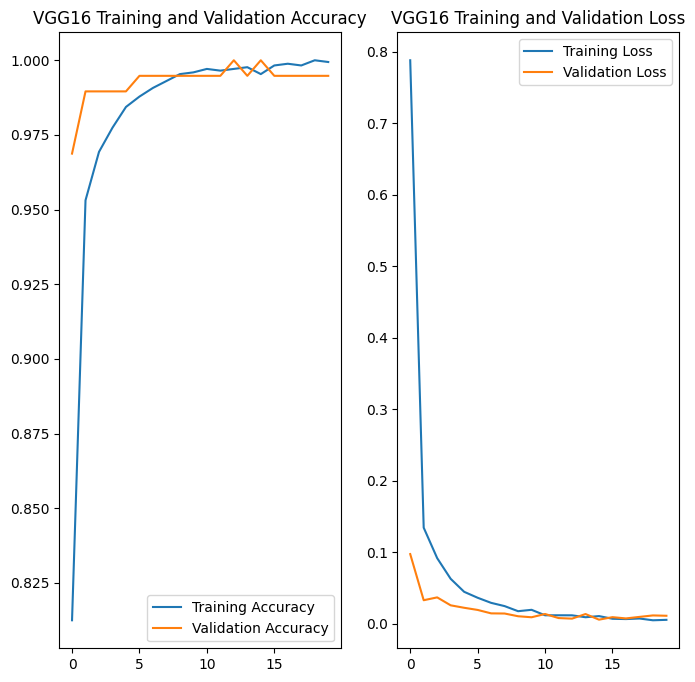

In [107]:
acc = history_vgg.history["accuracy"]
val_acc = history_vgg.history["val_accuracy"]

loss = history_vgg.history["loss"]
val_loss = history_vgg.history["val_loss"]

plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS_VGG), acc, label="Training Accuracy")
plt.plot(range(EPOCHS_VGG), val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("VGG16 Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS_VGG), loss, label="Training Loss")
plt.plot(range(EPOCHS_VGG), val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("VGG16 Training and Validation Loss")

plt.show()

                       precision    recall  f1-score   support

Potato___Early_blight       1.00      1.00      1.00       135
 Potato___Late_blight       1.00      1.00      1.00       107
     Potato___healthy       1.00      1.00      1.00        14

             accuracy                           1.00       256
            macro avg       1.00      1.00      1.00       256
         weighted avg       1.00      1.00      1.00       256



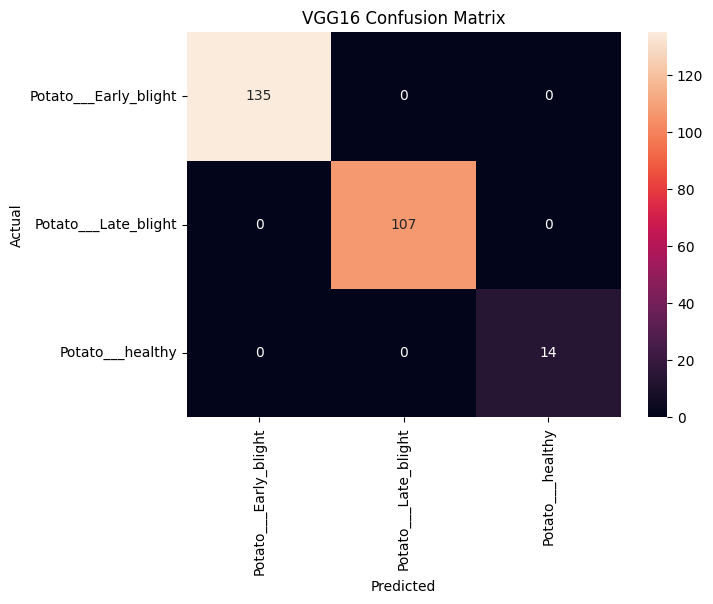

In [108]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model_vgg.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VGG16 Confusion Matrix")

plt.show()